<a href="https://colab.research.google.com/github/anhnhat25dev/TH_DEEPLEARNING/blob/main/Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cài đặt CNN

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [ ]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [ ]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


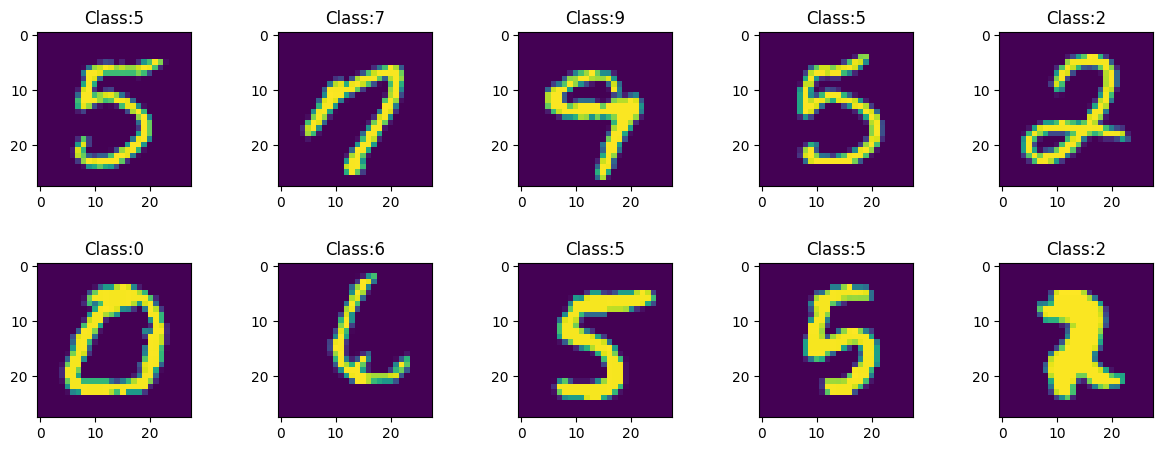

In [ ]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


2. xây dựng mô hình CNN


In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation = 'softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.8322 - loss: 0.5901 - val_accuracy: 0.9355 - val_loss: 0.2139
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9574 - loss: 0.1450 - val_accuracy: 0.9610 - val_loss: 0.1286
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9721 - loss: 0.0958 - val_accuracy: 0.9620 - val_loss: 0.1129
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - accuracy: 0.9774 - loss: 0.0744 - val_accuracy: 0.9695 - val_loss: 0.0930
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9812 - loss: 0.0599 - val_accuracy: 0.9750 - val_loss: 0.0781
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9837 - loss: 0.0542 - val_accuracy: 0.9765 - val_loss: 0.0780
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9790 - val_loss: 0.0695
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - accuracy: 0.9873 - loss: 0.037

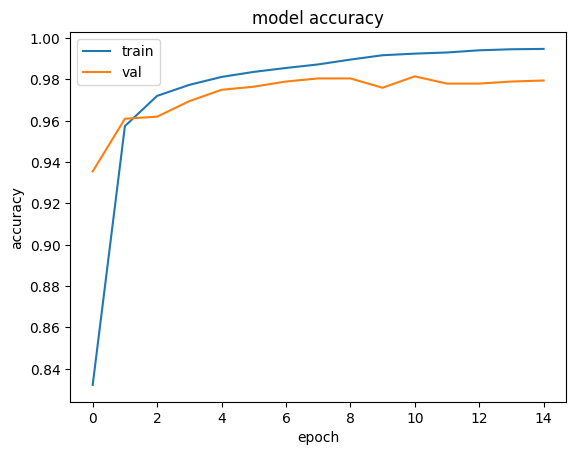

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

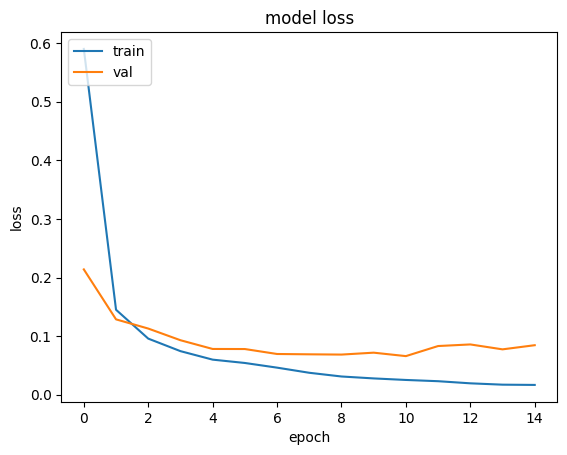

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
#đánh giá mô hình
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9830 - loss: 0.0615
Test loss: 0.06146658957004547
Test accuracy: 0.9829983115196228


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[6.8748144e-05 5.7910795e-05 9.9986863e-01 3.3734072e-08 7.8741994e-18
  2.0469068e-15 4.6783207e-06 6.2310555e-16 1.3059834e-08 1.9626975e-20]]
2 2


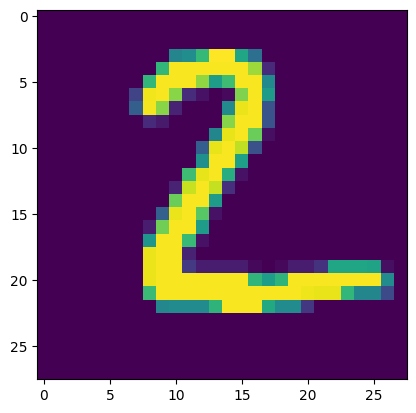

In [ ]:
#dự báo nhãn cho ảnh sử dụng CNN
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [ ]:
#luu tham số mô hình CNN
model.save_weights('model_weights.weights.h5')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
[[5.7139811e-08 9.9995434e-01 1.0104825e-05 3.5713134e-07 2.0678306e-05
  1.3810543e-08 5.4255048e-07 3.9252936e-06 1.0035419e-05 5.0630355e-10]]
1 1


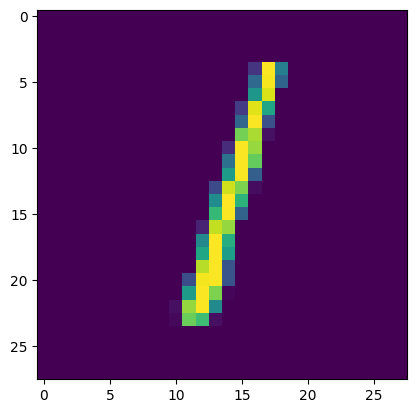

In [ ]:
#nạp lại mô hình và tham số
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

# SỬA TẠI ĐÂY: Bỏ model.add và dùng đúng tên file đã lưu ở bước trước
model.load_weights('model_weights.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

Bài Tập

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Input
from keras.models import Sequential
import matplotlib.pyplot as plt

In [ ]:
# Tải bộ dữ liệu CIFAR10 có sẵn
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Chuẩn hóa dữ liệu ảnh về khoảng [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Định nghĩa các tham số
num_classes = 10
input_shape = (32, 32, 3) # Ảnh màu 32x32 với 3 kênh màu (RGB)

# Chuyển đổi nhãn sang One-hot vector
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("Kích thước X_train:", X_train.shape)
print("Kích thước y_train:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Kích thước X_train: (50000, 32, 32, 3)
Kích thước y_train: (50000, 10)


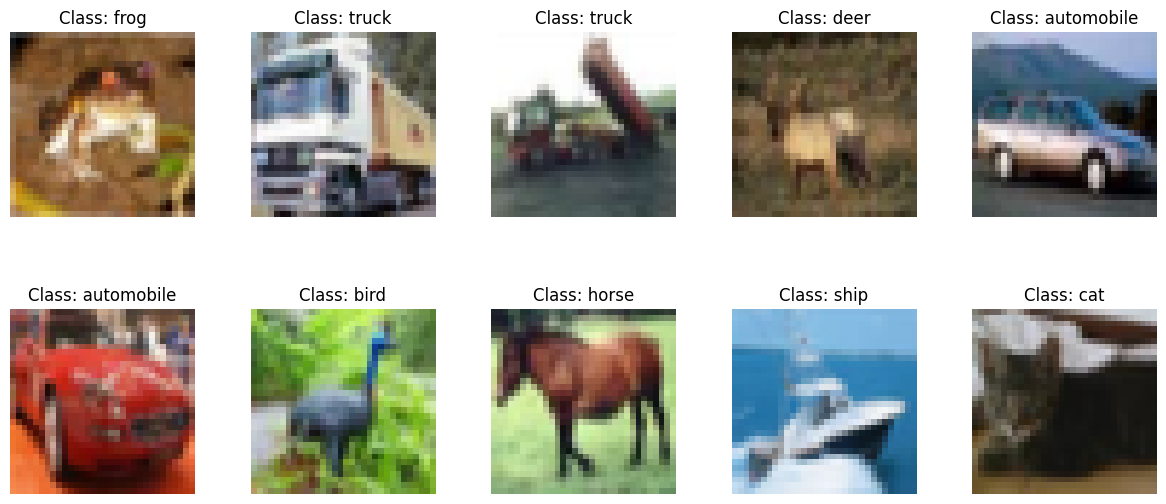

In [ ]:
# Danh sách các nhãn tương ứng theo mô tả của đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i]) # Không cần .reshape vì ảnh đã sẵn dạng (32,32,3)
    label_index = np.argmax(y_train[i])
    ax[i].title.set_text(f'Class: {class_names[label_index]}')
    ax[i].axis('off')
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))

# Khối CNN thứ nhất
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối CNN thứ hai
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Phẳng hóa và kết nối đầy đủ (Dense)
model.add(Flatten())
model.add(Dense(128, activation='relu')) # Thêm một lớp ẩn giúp học tốt hơn cấu trúc ảnh màu
model.add(Dense(units=num_classes, activation='softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_fit = model.fit(X_train, y_train, batch_size=64, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 129ms/step - accuracy: 0.4924 - loss: 1.4298 - val_accuracy: 0.5588 - val_loss: 1.2292
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.6307 - loss: 1.0563 - val_accuracy: 0.6482 - val_loss: 1.0324
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6817 - loss: 0.9210 - val_accuracy: 0.6410 - val_loss: 1.0302
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.7099 - loss: 0.8378 - val_accuracy: 0.6880 - val_loss: 0.9127
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.7337 - loss: 0.7656 - val_accuracy: 0.7056 - val_loss: 0.8706
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.7547 - loss: 0.7000 - val_accuracy: 0.7086 - val_loss: 0.8631
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.7809 - loss: 0.6275 - val_accuracy: 0.7204 - val_loss: 0.8407
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.8009 - loss: 0

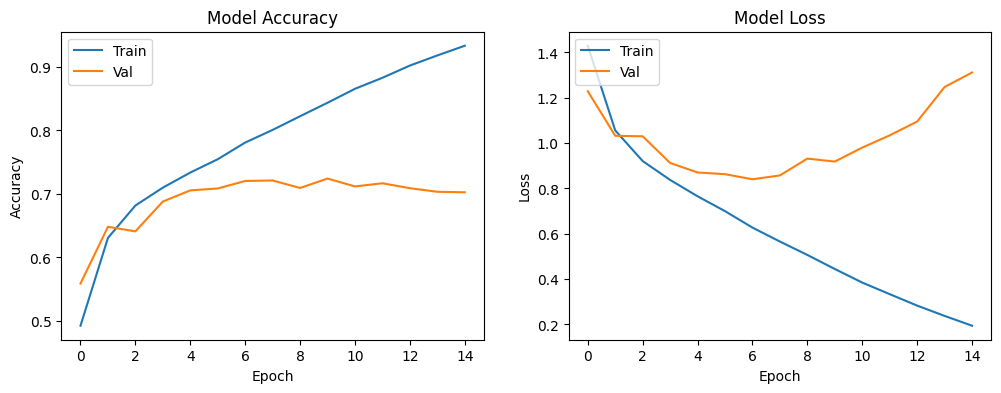

In [ ]:
# Đồ thị Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 5s - 18ms/step - accuracy: 0.6946 - loss: 1.3684
Test loss: 1.3684290647506714
Test accuracy: 0.694599986076355


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Nhãn dự đoán: 3 (cat)
Nhãn thực tế: 3 (cat)


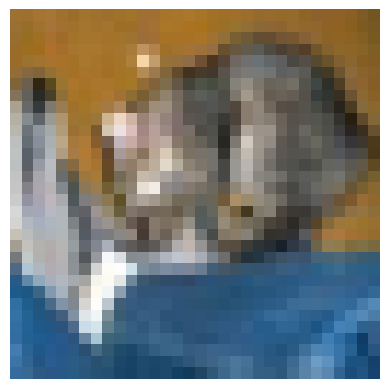

In [ ]:
#test 1 ảnh
predict = model.predict(X_test[:1])
pred_label = np.argmax(predict)
true_label = np.argmax(y_test[0])

print(f"Nhãn dự đoán: {pred_label} ({class_names[pred_label]})")
print(f"Nhãn thực tế: {true_label} ({class_names[true_label]})")

plt.imshow(X_test[0])
plt.axis('off')
plt.show()

In [ ]:
#lưu mô hình tham số
# Lưu trọng số với đuôi mở rộng chuẩn mới .weights.h5 nhằm tránh lỗi ValueError
model.save_weights('cifar10_model.weights.h5')
print("Đã lưu tham số mô hình thành công!")

Đã lưu tham số mô hình thành công!


Bài 5

In [ ]:
!pip install Flask tensorflow keras numpy

import os
os.makedirs('templates', exist_ok=True)
os.makedirs('static/uploads', exist_ok=True)
print("Đã khởi tạo xong các thư mục!")

Đã khởi tạo xong các thư mục!


In [ ]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Nhận Dạng Ảnh CIFAR10 - CNN</title>
    <style>
        body { font-family: 'Segoe UI', sans-serif; background-color: #f4f6f9; padding: 40px 20px; display: flex; justify-content: center; }
        .container { background: #ffffff; padding: 30px; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.05); max-width: 500px; width: 100%; text-align: center; }
        h2 { color: #333; margin-bottom: 20px; }
        .upload-section { border: 2px dashed #cbd5e1; padding: 20px; border-radius: 8px; background: #f8fafc; margin-bottom: 20px; }
        .btn-predict { background-color: #3b82f6; color: white; border: none; padding: 10px 25px; font-size: 16px; border-radius: 6px; cursor: pointer; }
        .btn-predict:hover { background-color: #2563eb; }
        .result-box { margin-top: 30px; padding: 15px; background: #f0fdf4; border: 1px solid #bbf7d0; border-radius: 8px; }
        .preview-img { max-width: 200px; max-height: 200px; border-radius: 8px; margin-top: 15px; }
    </style>
</head>
<body>
<div class="container">
    <h2>Mô hình Nhận dạng Ảnh CNN</h2>
    <p style="color: #64748b; font-size: 14px;">Hỗ trợ nhận dạng: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck.</p>

    <form action="/" method="POST" enctype="multipart/form-data">
        <div class="upload-section">
            <input type="file" name="file" accept="image/*" required>
        </div>
        <button type="submit" class="btn-predict">Dự đoán ảnh</button>
    </form>

    {% if prediction %}
        <div class="result-box">
            <h3>KẾT QUẢ DỰ ĐOÁN</h3>
            <p>Đối tượng: <strong>{{ prediction.upper() }}</strong></p>
            <p>Độ tin cậy: <span style="color: #15803d; font-weight: bold;">{{ score }}</span></p>
            <img class="preview-img" src="{{ inserted_img }}" alt="Ảnh đã tải lên">
        </div>
    {% endif %}
</div>
</body>
</html>

Overwriting templates/index.html


In [ ]:
%%writefile app.py
import os
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Input
from keras.models import Sequential
from flask import Flask, render_template, request, redirect

app = Flask(__name__)
UPLOAD_FOLDER = 'static/uploads/'
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

def create_model():
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(units=10, activation='softmax'))
    return model

# Khởi tạo mô hình và nạp trọng số củ
model = create_model()
if os.path.exists('cifar10_model.weights.h5'):
    model.load_weights('cifar10_model.weights.h5')
    print("--- Nạp file trọng số thành công! ---")
else:
    print("--- CẢNH BÁO: Không tìm thấy file 'cifar10_model.weights.h5'. Vui lòng upload file vào Colab! ---")

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def preprocess_image(image_path):
    img = keras.utils.load_img(image_path, target_size=(32, 32))
    img_array = keras.utils.img_to_array(img)
    img_array = img_array.astype('float32') / 255.0
    return np.expand_dims(img_array, axis=0)

@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':
        if 'file' not in request.files: return redirect(request.url)
        file = request.files['file']
        if file.filename == '': return redirect(request.url)

        if file:
            filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
            file.save(filepath)

            processed_img = preprocess_image(filepath)
            predictions = model.predict(processed_img)

            class_idx = np.argmax(predictions[0])
            result_label = CLASS_NAMES[class_idx]
            confidence = float(predictions[0][class_idx]) * 100

            return render_template('index.html', inserted_img=filepath, prediction=result_label, score=f"{confidence:.2f}%")
    return render_template('index.html')

if __name__ == '__main__':
    app.run(port=5000)

Writing app.py


In [ ]:
from google.colab.output import eval_js

# Tạo đường dẫn kết nối từ bên ngoài vào port 5000 của Colab
print("Mẹo: Bấm vào đường link bên dưới để mở giao diện WEB:")
print(eval_js("google.colab.kernel.proxyPort(5000)"))

# Tiến hành khởi chạy server Flask vừa tạo
!python app.py

Mẹo: Bấm vào đường link bên dưới để mở giao diện WEB:
https://5000-m-s-kkb-use1d1-23arnz5pkl5fs-d.us-east1-1.prod.colab.dev
2026-05-27 01:41:19.505196: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
--- Nạp file trọng số thành công! ---
 * Serving Flask app 'app'
 * Debug mode: off
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
^C
